
Dataset size = 1000
Bloom insert : 7.941 ± 0.865 ms
Bloom query  : 7.889 ± 0.866 ms
Bloom FP rate: 0.000000
Bloom mem    : 0.801 MB
CMS insert   : 8.478 ± 0.821 ms
CMS query    : 7.665 ± 0.821 ms
CMS avg error: 0.000011
CMS mem      : 0.281 MB

Dataset size = 10000
Bloom insert : 78.027 ± 5.714 ms
Bloom query  : 7.752 ± 0.952 ms
Bloom FP rate: 0.002720
Bloom mem    : 0.804 MB
CMS insert   : 81.795 ± 6.408 ms
CMS query    : 8.146 ± 0.622 ms
CMS avg error: 0.027090
CMS mem      : 0.281 MB

Dataset size = 100000
Bloom insert : 810.659 ± 42.174 ms
Bloom query  : 8.062 ± 1.227 ms
Bloom FP rate: 0.169810
Bloom mem    : 0.805 MB
CMS insert   : 836.974 ± 40.652 ms
CMS query    : 8.381 ± 0.893 ms
CMS avg error: 0.662670
CMS mem      : 0.281 MB


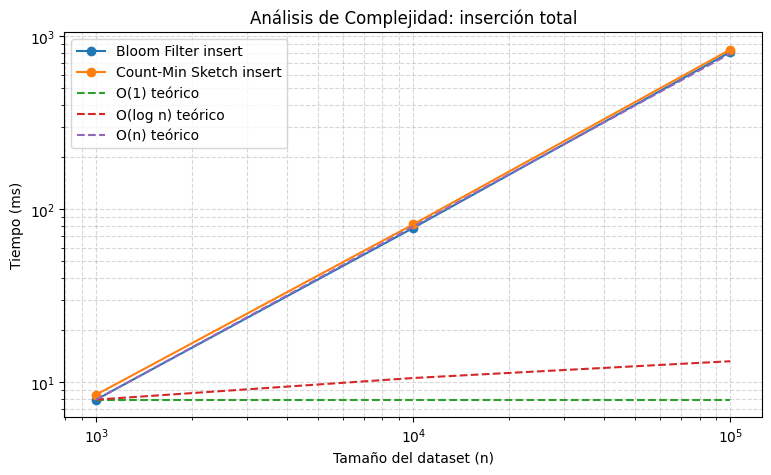

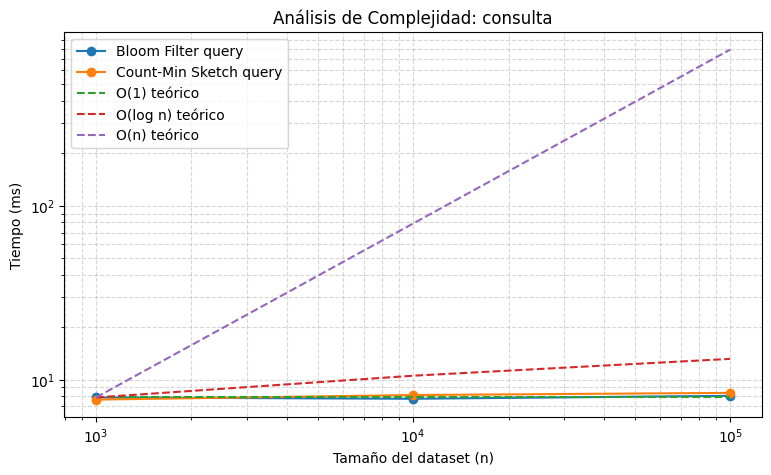

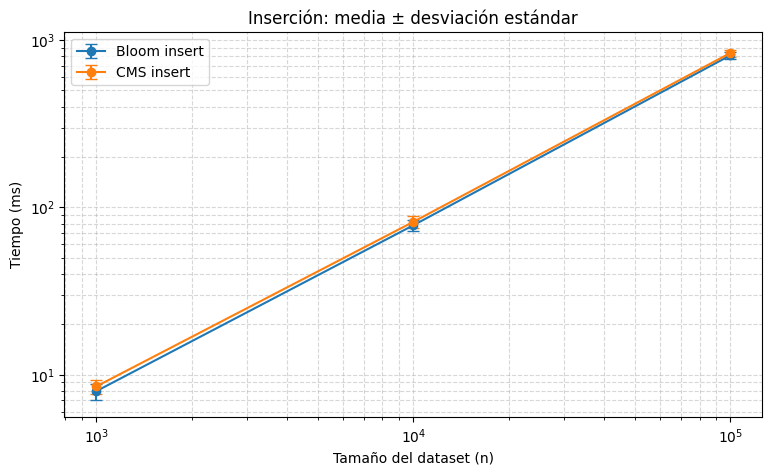

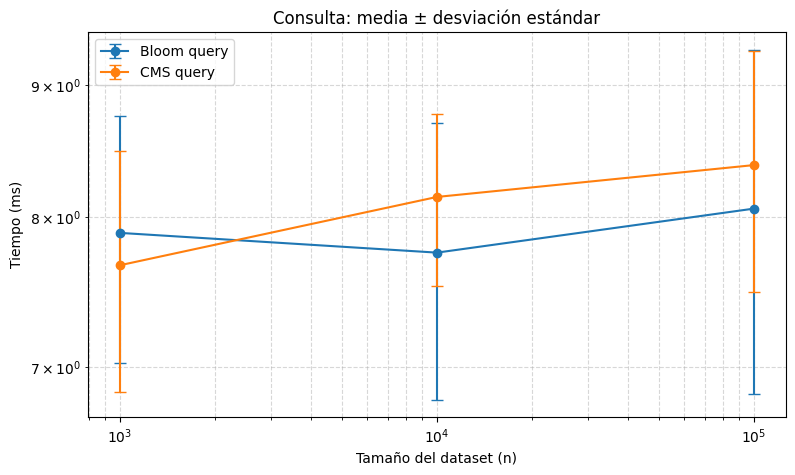

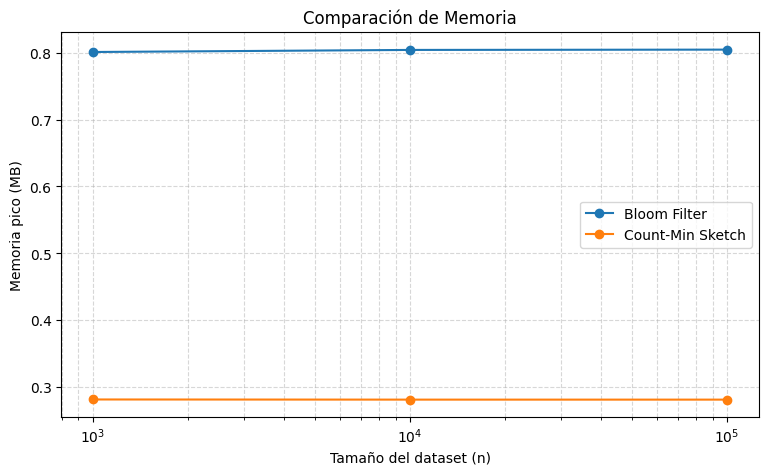

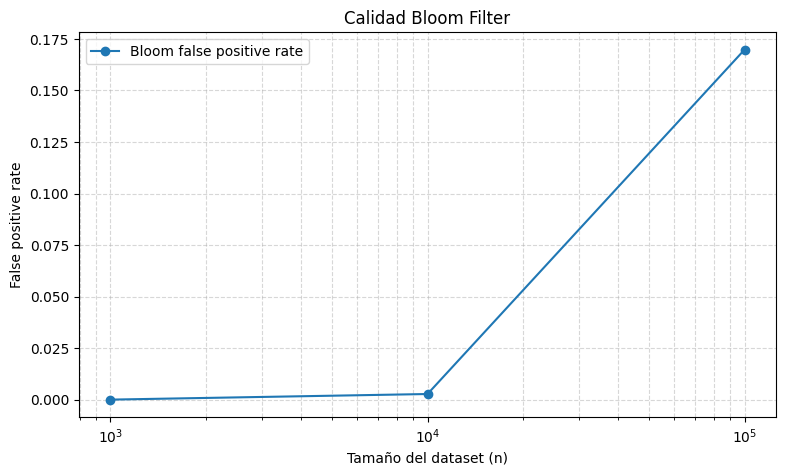

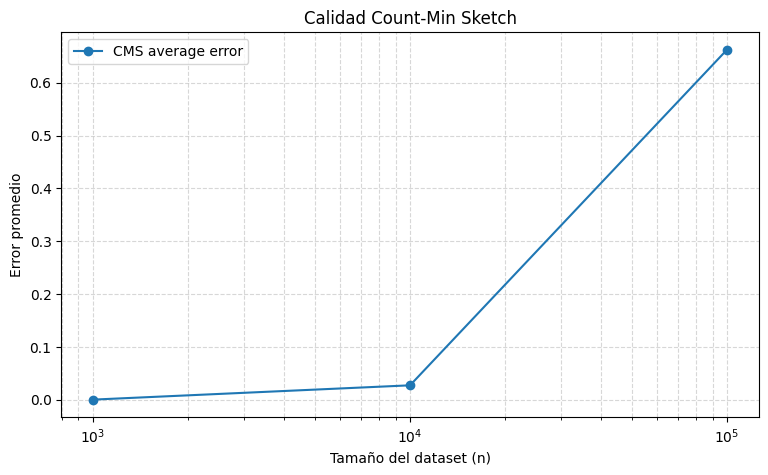


         n |    BF insert |     BF query |   BF FP rate |       BF Mem |   CMS insert |    CMS query |      CMS err |      CMS Mem
      1000 |        7.941 |        7.889 |     0.000000 |        0.801 |        8.478 |        7.665 |     0.000011 |        0.281
     10000 |       78.027 |        7.752 |     0.002720 |        0.804 |       81.795 |        8.146 |     0.027090 |        0.281
    100000 |      810.659 |        8.062 |     0.169810 |        0.805 |      836.974 |        8.381 |     0.662670 |        0.281


In [1]:
# =========================================================
# EXPERIMENTACIÓN Y ANÁLISIS
# Detección de Usuarios Duplicados / Bots
# Comparación: Bloom Filter vs Count-Min Sketch
# =========================================================

import random
import time
import math
import statistics
import tracemalloc
import hashlib
import matplotlib.pyplot as plt


# =========================================================
# 1. BLOOM FILTER
# =========================================================
class BloomFilter:
    def __init__(self, size_bits=100000, num_hashes=7):
        self.size_bits = size_bits
        self.num_hashes = num_hashes
        self.bit_array = [0] * size_bits
        self.seeds = [i * 131 + 7 for i in range(num_hashes)]

    def _hash(self, item, seed):
        return int(
            hashlib.blake2b((item + str(seed)).encode(), digest_size=8).hexdigest(),
            16
        ) % self.size_bits

    def add(self, item):
        for seed in self.seeds:
            idx = self._hash(item, seed)
            self.bit_array[idx] = 1

    def contains(self, item):
        for seed in self.seeds:
            idx = self._hash(item, seed)
            if self.bit_array[idx] == 0:
                return False
        return True


# =========================================================
# 2. COUNT-MIN SKETCH
# =========================================================
class CountMinSketch:
    def __init__(self, width=5000, depth=7):
        self.width = width
        self.depth = depth
        self.table = [[0] * width for _ in range(depth)]
        self.seeds = [i * 131 + 17 for i in range(depth)]

    def _hash(self, item, seed):
        return int(
            hashlib.blake2b((item + str(seed)).encode(), digest_size=8).hexdigest(),
            16
        ) % self.width

    def add(self, item, count=1):
        for i, seed in enumerate(self.seeds):
            idx = self._hash(item, seed)
            self.table[i][idx] += count

    def estimate(self, item):
        vals = []
        for i, seed in enumerate(self.seeds):
            idx = self._hash(item, seed)
            vals.append(self.table[i][idx])
        return min(vals)


# =========================================================
# 3. GENERADOR DE DATASET
# =========================================================
# Simula:
# - usuarios normales: pocas IPs
# - usuarios sospechosos/bots: muchas IPs distintas

def generate_user_ip_dataset(n, num_users=5000, num_ips=50000, suspicious_ratio=0.02, seed=42):
    random.seed(seed)

    users = [f"user_{i}" for i in range(num_users)]
    ips = [f"192.168.{i//256}.{i%256}" for i in range(num_ips)]

    suspicious_users = set(random.sample(users, max(1, int(num_users * suspicious_ratio))))

    data = []

    for _ in range(n):
        user = random.choice(users)

        # Usuarios sospechosos usan muchas IPs
        if user in suspicious_users:
            ip = random.choice(ips)
        else:
            # usuario normal tiende a usar un subconjunto pequeño
            base = abs(hash(user)) % max(1000, num_ips - 20)
            ip = ips[base + random.randint(0, 3)]

        data.append((user, ip))

    return data, suspicious_users


# =========================================================
# 4. OPERACIONES CRÍTICAS
# =========================================================
# Bloom:
#   - add(user|ip)
#   - contains(user|ip)
#
# CMS:
#   - add(user)
#   - estimate(user)
#
# También se puede usar sobre el par "user|ip".

def pair_key(user, ip):
    return f"{user}|{ip}"


# =========================================================
# 5. BENCHMARK BLOOM FILTER
# =========================================================
def benchmark_bloom(data, query_items, size_bits=100000, num_hashes=7):
    bf = BloomFilter(size_bits=size_bits, num_hashes=num_hashes)

    # insert
    t0 = time.perf_counter()
    for user, ip in data:
        bf.add(pair_key(user, ip))
    t1 = time.perf_counter()
    insert_ms = (t1 - t0) * 1000

    # query
    t0 = time.perf_counter()
    positives = 0
    for item in query_items:
        if bf.contains(item):
            positives += 1
    t1 = time.perf_counter()
    query_ms = (t1 - t0) * 1000

    return bf, insert_ms, query_ms, positives


# =========================================================
# 6. BENCHMARK COUNT-MIN SKETCH
# =========================================================
def benchmark_cms(data, query_users, width=5000, depth=7):
    cms = CountMinSketch(width=width, depth=depth)

    # insert
    t0 = time.perf_counter()
    for user, ip in data:
        cms.add(user, 1)
    t1 = time.perf_counter()
    insert_ms = (t1 - t0) * 1000

    # query
    t0 = time.perf_counter()
    estimates = []
    for user in query_users:
        estimates.append(cms.estimate(user))
    t1 = time.perf_counter()
    query_ms = (t1 - t0) * 1000

    return cms, insert_ms, query_ms, estimates


# =========================================================
# 7. MÉTRICAS DE CALIDAD
# =========================================================
def bloom_false_positive_rate(bf, negatives):
    false_positives = 0
    for item in negatives:
        if bf.contains(item):
            false_positives += 1
    return false_positives / len(negatives) if negatives else 0


def cms_average_error(cms, real_counts, queries):
    errors = []
    for q in queries:
        est = cms.estimate(q)
        real = real_counts.get(q, 0)
        errors.append(est - real)
    return sum(errors) / len(errors) if errors else 0


# =========================================================
# 8. MEMORIA
# =========================================================
def memory_test_bloom(data, size_bits=100000, num_hashes=7):
    tracemalloc.start()
    bf = BloomFilter(size_bits=size_bits, num_hashes=num_hashes)
    for user, ip in data:
        bf.add(pair_key(user, ip))
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return current / 10**6, peak / 10**6


def memory_test_cms(data, width=5000, depth=7):
    tracemalloc.start()
    cms = CountMinSketch(width=width, depth=depth)
    for user, ip in data:
        cms.add(user, 1)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return current / 10**6, peak / 10**6


# =========================================================
# 9. CURVAS TEÓRICAS
# =========================================================
def scale_curve(reference_times, base_curve):
    factor = reference_times[0] / base_curve[0]
    return [factor * x for x in base_curve]

def make_theoretical_curves(sizes, reference_times):
    O1 = scale_curve(reference_times, [1 for _ in sizes])
    Ologn = scale_curve(reference_times, [math.log2(n) for n in sizes])
    On = scale_curve(reference_times, [n for n in sizes])
    Onlogn = scale_curve(reference_times, [n * math.log2(n) for n in sizes])
    return O1, Ologn, On, Onlogn


# =========================================================
# 10. EXPERIMENTO COMPLETO
# =========================================================
def run_full_experiment(sizes, repeats=100, seed_base=1000):
    results = {
        "bf_insert_mean": [], "bf_insert_std": [],
        "bf_query_mean": [], "bf_query_std": [],
        "bf_fp_mean": [], "bf_mem_peak": [],

        "cms_insert_mean": [], "cms_insert_std": [],
        "cms_query_mean": [], "cms_query_std": [],
        "cms_err_mean": [], "cms_mem_peak": [],
    }

    for idx, n in enumerate(sizes):
        print(f"\n==============================")
        print(f"Dataset size = {n}")
        print(f"==============================")

        bf_insert_times = []
        bf_query_times = []
        bf_fp_rates = []

        cms_insert_times = []
        cms_query_times = []
        cms_errors = []

        # memoria una vez por tamaño
        mem_data, _ = generate_user_ip_dataset(n, seed=seed_base + idx)
        _, bf_peak = memory_test_bloom(mem_data)
        _, cms_peak = memory_test_cms(mem_data)

        results["bf_mem_peak"].append(bf_peak)
        results["cms_mem_peak"].append(cms_peak)

        for r in range(repeats):
            seed = seed_base + idx * 1000 + r
            data, suspicious_users = generate_user_ip_dataset(n, seed=seed)

            # ground truth para CMS
            real_counts = {}
            for user, ip in data:
                real_counts[user] = real_counts.get(user, 0) + 1

            # queries
            query_users = random.sample(list(real_counts.keys()), min(1000, len(real_counts)))

            # queries para Bloom: positivos reales
            positive_queries = [pair_key(u, ip) for u, ip in random.sample(data, min(1000, len(data)))]

            # queries negativas para Bloom
            negative_queries = []
            for i in range(len(positive_queries)):
                negative_queries.append(f"fake_user_{idx}_{r}_{i}|10.10.{i//256}.{i%256}")

            # Bloom
            bf, bf_insert_ms, bf_query_ms, _ = benchmark_bloom(data, positive_queries)
            bf_fp = bloom_false_positive_rate(bf, negative_queries)

            bf_insert_times.append(bf_insert_ms)
            bf_query_times.append(bf_query_ms)
            bf_fp_rates.append(bf_fp)

            # CMS
            cms, cms_insert_ms, cms_query_ms, _ = benchmark_cms(data, query_users)
            cms_err = cms_average_error(cms, real_counts, query_users)

            cms_insert_times.append(cms_insert_ms)
            cms_query_times.append(cms_query_ms)
            cms_errors.append(cms_err)

        results["bf_insert_mean"].append(statistics.mean(bf_insert_times))
        results["bf_insert_std"].append(statistics.stdev(bf_insert_times))
        results["bf_query_mean"].append(statistics.mean(bf_query_times))
        results["bf_query_std"].append(statistics.stdev(bf_query_times))
        results["bf_fp_mean"].append(statistics.mean(bf_fp_rates))

        results["cms_insert_mean"].append(statistics.mean(cms_insert_times))
        results["cms_insert_std"].append(statistics.stdev(cms_insert_times))
        results["cms_query_mean"].append(statistics.mean(cms_query_times))
        results["cms_query_std"].append(statistics.stdev(cms_query_times))
        results["cms_err_mean"].append(statistics.mean(cms_errors))

        print(f"Bloom insert : {results['bf_insert_mean'][-1]:.3f} ± {results['bf_insert_std'][-1]:.3f} ms")
        print(f"Bloom query  : {results['bf_query_mean'][-1]:.3f} ± {results['bf_query_std'][-1]:.3f} ms")
        print(f"Bloom FP rate: {results['bf_fp_mean'][-1]:.6f}")
        print(f"Bloom mem    : {results['bf_mem_peak'][-1]:.3f} MB")

        print(f"CMS insert   : {results['cms_insert_mean'][-1]:.3f} ± {results['cms_insert_std'][-1]:.3f} ms")
        print(f"CMS query    : {results['cms_query_mean'][-1]:.3f} ± {results['cms_query_std'][-1]:.3f} ms")
        print(f"CMS avg error: {results['cms_err_mean'][-1]:.6f}")
        print(f"CMS mem      : {results['cms_mem_peak'][-1]:.3f} MB")

    return results


# =========================================================
# 11. PARÁMETROS
# =========================================================
# Para Colab conviene empezar así:
sizes = [10**3, 10**4, 10**5]

# Si tu entorno aguanta:
# sizes = [10**3, 10**4, 10**5, 10**6, 10**7]

repeats = 100


# =========================================================
# 12. EJECUTAR
# =========================================================
results = run_full_experiment(sizes=sizes, repeats=repeats)


# =========================================================
# 13. GRÁFICO LOG-LOG: INSERT
# =========================================================
bf_insert = results["bf_insert_mean"]
cms_insert = results["cms_insert_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, bf_insert)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, bf_insert, 'o-', label='Bloom Filter insert')
plt.loglog(sizes, cms_insert, 'o-', label='Count-Min Sketch insert')
plt.loglog(sizes, O1, '--', label='O(1) teórico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.loglog(sizes, On, '--', label='O(n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: inserción total')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 14. GRÁFICO LOG-LOG: QUERY
# =========================================================
bf_query = results["bf_query_mean"]
cms_query = results["cms_query_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, bf_query)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, bf_query, 'o-', label='Bloom Filter query')
plt.loglog(sizes, cms_query, 'o-', label='Count-Min Sketch query')
plt.loglog(sizes, O1, '--', label='O(1) teórico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.loglog(sizes, On, '--', label='O(n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: consulta')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 15. BARRAS DE ERROR
# =========================================================
plt.figure(figsize=(9, 5))
plt.errorbar(sizes, results["bf_insert_mean"], yerr=results["bf_insert_std"], fmt='o-', capsize=4, label='Bloom insert')
plt.errorbar(sizes, results["cms_insert_mean"], yerr=results["cms_insert_std"], fmt='o-', capsize=4, label='CMS insert')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Inserción: media ± desviación estándar')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

plt.figure(figsize=(9, 5))
plt.errorbar(sizes, results["bf_query_mean"], yerr=results["bf_query_std"], fmt='o-', capsize=4, label='Bloom query')
plt.errorbar(sizes, results["cms_query_mean"], yerr=results["cms_query_std"], fmt='o-', capsize=4, label='CMS query')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Consulta: media ± desviación estándar')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 16. MEMORIA
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(sizes, results["bf_mem_peak"], 'o-', label='Bloom Filter')
plt.plot(sizes, results["cms_mem_peak"], 'o-', label='Count-Min Sketch')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Memoria pico (MB)')
plt.title('Comparación de Memoria')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 17. CALIDAD
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(sizes, results["bf_fp_mean"], 'o-', label='Bloom false positive rate')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('False positive rate')
plt.title('Calidad Bloom Filter')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(sizes, results["cms_err_mean"], 'o-', label='CMS average error')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Error promedio')
plt.title('Calidad Count-Min Sketch')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 18. RESUMEN FINAL
# =========================================================
print("\n" + "=" * 120)
print(f"{'n':>10} | {'BF insert':>12} | {'BF query':>12} | {'BF FP rate':>12} | {'BF Mem':>12} | {'CMS insert':>12} | {'CMS query':>12} | {'CMS err':>12} | {'CMS Mem':>12}")
print("=" * 120)

for i, n in enumerate(sizes):
    print(
        f"{n:>10} | "
        f"{results['bf_insert_mean'][i]:>12.3f} | "
        f"{results['bf_query_mean'][i]:>12.3f} | "
        f"{results['bf_fp_mean'][i]:>12.6f} | "
        f"{results['bf_mem_peak'][i]:>12.3f} | "
        f"{results['cms_insert_mean'][i]:>12.3f} | "
        f"{results['cms_query_mean'][i]:>12.3f} | "
        f"{results['cms_err_mean'][i]:>12.6f} | "
        f"{results['cms_mem_peak'][i]:>12.3f}"
    )